In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **CREATE A MINI-LLM FROM SCRATCH**

**DATA**
ENVIRONMENTAL CHECK

In [2]:
import sys, torch
print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0), "| count:", torch.cuda.device_count())

python: 3.12.13
torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4 | count: 2


**LOAD AND INSPECT DATASET**

In [3]:
from datasets import load_dataset

ds = load_dataset(
    "HuggingFaceFW/fineweb-edu",
    name="sample-10BT",
    split="train",
    streaming=True,
)

for i, ex in enumerate(ds):
    print(f"--- doc {i} ---")
    print("fields:", list(ex.keys()))
    print("score:", ex["score"], "| token_count:", ex["token_count"])
    print(ex["text"][:300].replace("\n", " "), "...\n")
    if i == 2:
        break

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

--- doc 0 ---
fields: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score']
score: 2.75 | token_count: 845
The Independent Jane For all the love, romance and scandal in Jane Austen’s books, what they are really about is freedom and independence. Independence of thought and the freedom to choose. Elizabeth’s refusal of Mr. Collins offer of marriage showed an independence seldom seen in heroines of the day ...

--- doc 1 ---
fields: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score']
score: 2.5625 | token_count: 1055
Taking Play Seriously By ROBIN MARANTZ HENIG Published: February 17, 2008 On a drizzly Tuesday night in late January, 200 people came out to hear a psychiatrist talk rhapsodically about play -- not just the intense, joyous play of children, but play for all people, at all ages, at all times. (All sp ...

--- doc 2 ---
fields: ['text', 'id', 'dump', 'url', 'file_p

# STAGE 1: TOKENIZER(TIKTOKEN)
**WE USE OPENAI
* Vocab size: 50,257 (50,256 BPE tokens + `<|endoftext|>` with id 50256)
* Fits in uint16 (max 65,535), so token shards take 2 bytes per token
* Byte-level, so any text encodes without unknown tokens**

In [4]:
try:
    import tiktoken
except:
    !pip install -q tiktoken
    import tiktoken

enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token
print("vocab size:", enc.n_vocab, "| eot id:", EOT)

tests = [
    "Hello, Guys!!",
    "GUten MOrgen, wir ghets dir.", #germany
    "Habari yako", #swahili
    
]

for s in tests:
    ids = enc.encode_ordinary(s)
    back = enc.decode(ids)
    print(f"{len(s):3d} chars -> {len(ids):3d} tokens | round trip ok: {back == s}")
    print(" ", ids[:12], "...")
    

vocab size: 50257 | eot id: 50256
 13 chars ->   4 tokens | round trip ok: True
  [15496, 11, 29899, 3228] ...
 28 chars ->  13 tokens | round trip ok: True
  [38022, 1452, 337, 5574, 5235, 11, 266, 343, 308, 258, 912, 26672] ...
 11 chars ->   5 tokens | round trip ok: True
  [39, 397, 2743, 331, 25496] ...


**COMPARE TIKTOKEN AND BPE AGAINST THE DATASET TOKEN COUNTS**

In [5]:
for i, ex in enumerate(ds):
    ids = enc.encode_ordinary(ex['text'])
    ids.append(EOT)
    print(f"doc {i}: ours={len(ids)} | dataset token_count={ex['token_count']}")
    if i == 4:
        break

doc 0: ours=846 | dataset token_count=845
doc 1: ours=1056 | dataset token_count=1055
doc 2: ours=137 | dataset token_count=136
doc 3: ours=3480 | dataset token_count=3479
doc 4: ours=1116 | dataset token_count=1115


In [6]:
s = "Tokenization splits unusual words like Kimathi into pieces."
ids = enc.encode_ordinary(s)
print([enc.decode([t]) for t in ids])

['Token', 'ization', ' splits', ' unusual', ' words', ' like', ' Kim', 'athi', ' into', ' pieces', '.']


# STAGE 3: SHARD THE DATA
Stream FineWeb-Edu, tokenize with tiktoken gpt2, and write uint16 shards.

- Subset: ~100M tokens for debugging the model and training loop
- Split by document: md5(doc id) % 100 < 5 goes to validation, the rest to train.
  Deterministic, so a restarted session can never leak a val doc into train.
- Each document is followed by <|endoftext|> (id 50256)
- Shards of 10M tokens: train_000.bin, ..., val_000.bin
- Tokenization runs in a multiprocessing pool, in batches of 2,000 docs.
  Batching keeps the stream from being read far ahead of the workers.

1. **TOKENIZE AND WRITE SHARDS**

In [7]:
import os, hashlib, multiprocessing as mp
from itertools import islice
import numpy as np
import tiktoken
from datasets import load_dataset

OUT = "/kaggle/working/shards"
os.makedirs(OUT, exist_ok=True)

SHARD  = 10_000_000     # tokens per shard
TARGET = 100_000_000    # total tokens for the debug subset
VAL_PCT = 5

enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token

def is_val(doc_id):
    return int(hashlib.md5(doc_id.encode()).hexdigest(), 16) % 100 < VAL_PCT

def work(args):
    doc_id, text = args
    ids = enc.encode_ordinary(text)
    ids.append(EOT)
    return is_val(doc_id), np.array(ids, dtype=np.uint16)

class ShardWriter:
    def __init__(self, split):
        self.split = split
        self.buf = np.empty(SHARD, dtype=np.uint16)
        self.n, self.idx, self.total = 0, 0, 0
    def add(self, toks):
        while len(toks):
            take = min(SHARD - self.n, len(toks))
            self.buf[self.n:self.n + take] = toks[:take]
            self.n += take
            toks = toks[take:]
            if self.n == SHARD:
                self.flush()
    def flush(self):
        if self.n == 0:
            return
        self.buf[:self.n].tofile(f"{OUT}/{self.split}_{self.idx:03d}.bin")
        self.total += self.n
        self.idx += 1
        self.n = 0

ds = load_dataset("HuggingFaceFW/fineweb-edu", name="sample-10BT",
                  split="train", streaming=True)
ds = ds.shuffle(seed=42, buffer_size=10_000)
it = ((ex["id"], ex["text"]) for ex in ds)

writers = {True: ShardWriter("val"), False: ShardWriter("train")}
count = 0

with mp.Pool(os.cpu_count()) as pool:
    while count < TARGET:
        batch = list(islice(it, 2000))
        if not batch:
            break
        for val, toks in pool.map(work, batch, chunksize=50):
            writers[val].add(toks)
            count += len(toks)
        print(f"{count/1e6:7.1f}M tokens", end="\r")

for w in writers.values():
    w.flush()

print(f"\ntrain: {writers[False].total/1e6:.1f}M tokens in {writers[False].idx} shards")
print(f"val:   {writers[True].total/1e6:.1f}M tokens in {writers[True].idx} shards")

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

  102.0M tokens
train: 96.9M tokens in 10 shards
val:   5.0M tokens in 1 shards


**VERIFY THE SHARDS**

In [8]:
import glob

for path in sorted(glob.glob(f"{OUT}/*.bin")):
    arr = np.memmap(path, dtype=np.uint16, mode="r")
    print(f"{os.path.basename(path)}: {len(arr):,} tokens | max id {arr.max()}")


#decode the start of the one train and the one val shard
for name in ("train_000.bin", "val_000.bin"):
    arr = np.memmap(f"{OUT}/{name}", dtype=np.uint16, mode="r")
    print(f"\n--- {name} ---")
    print(enc.decode(arr[:150].tolist()))

train_000.bin: 10,000,000 tokens | max id 50256
train_001.bin: 10,000,000 tokens | max id 50256
train_002.bin: 10,000,000 tokens | max id 50256
train_003.bin: 10,000,000 tokens | max id 50256
train_004.bin: 10,000,000 tokens | max id 50256
train_005.bin: 10,000,000 tokens | max id 50256
train_006.bin: 10,000,000 tokens | max id 50256
train_007.bin: 10,000,000 tokens | max id 50256
train_008.bin: 10,000,000 tokens | max id 50256
train_009.bin: 6,924,125 tokens | max id 50256
val_000.bin: 5,029,655 tokens | max id 50256

--- train_000.bin ---
a combination of one or more elementary reaction steps which start with the appropriate reactants and end with the appropriate product(s)
a description of the path, or sequence of steps, by which a reaction occurs
a description of the path that a reaction takes
a detailed description of how a chemical reaction occurs
a detailed description of the way a reaction occurs and is based on the known experimental data about the reaction
a detailed (theoret

# STAGE 4: DATA LOADER
The model learns next-token prediction. For a window of block_size + 1 tokens
t0..tN, we build:

- x = t0..t(N-1)   (input)
- y = t1..tN       (target, x shifted one token ahead)

So at every position i, the model sees x[0..i] and must predict y[i] = x[i+1].
One window therefore gives block_size training examples at once.

Design:
- Shards are memory-mapped (np.memmap): the OS pages in only what we touch,
  so 200 MB or 200 GB costs the same RAM.
- Each sample picks a random shard (weighted by size), then a random offset.
  Windows never cross a shard boundary.
- Windows can span document boundaries (they contain <|endoftext|>).
  This is standard: the model learns that a new document starts after it.
- Validation uses its own shard and never touches train shards.

In [9]:
import glob, os
import numpy as np
import torch

SHARD_DIR = "/kaggle/working/shards"

class DataLoader:
    def __init__(self, split, batch_size, block_size, device, seed=1337):
        paths = sorted(glob.glob(f"{SHARD_DIR}/{split}_*.bin"))
        assert paths, f"no shards found for split '{split}'"
        self.data = [np.memmap(p, dtype=np.uint16, mode="r") for p in paths]
        sizes = np.array([len(d) for d in self.data], dtype=np.float64)
        self.probs = sizes / sizes.sum()
        self.B, self.T, self.device = batch_size, block_size, device
        self.rng = np.random.default_rng(seed)
        self.total = int(sizes.sum())

    def get_batch(self):
        xs, ys = [], []
        for _ in range(self.B):
            d = self.data[self.rng.choice(len(self.data), p=self.probs)]
            i = int(self.rng.integers(0, len(d) - self.T - 1))
            chunk = d[i : i + self.T + 1].astype(np.int64)
            xs.append(chunk[:-1])
            ys.append(chunk[1:])
        x = torch.from_numpy(np.stack(xs))
        y = torch.from_numpy(np.stack(ys))
        return x.to(self.device), y.to(self.device)

device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader("train", batch_size=8, block_size=256, device=device)
val_loader   = DataLoader("val",   batch_size=8, block_size=256, device=device, seed=0)
print(f"train tokens: {train_loader.total:,} | val tokens: {val_loader.total:,}")

train tokens: 96,924,125 | val tokens: 5,029,655


**the checks**

In [10]:
x, y = train_loader.get_batch()
print("x:", tuple(x.shape), x.dtype, "| y:", tuple(y.shape), y.dtype)

# 1. y must be x shifted one token ahead
assert torch.equal(x[:, 1:], y[:, :-1]), "shift is wrong"
print("shift check passed")

# 2. ids must be valid
assert x.max().item() < 50257 and x.min().item() >= 0
print("id range ok")

# 3. read it with your own eyes
print("\n--- x[0], first 60 tokens ---")
print(enc.decode(x[0, :60].tolist()))
print("\n--- y[0], first 60 tokens (should start one token later) ---")
print(enc.decode(y[0, :60].tolist()))

# 4. val and train must not share a batch source
xv, yv = val_loader.get_batch()
print("\nval batch:", tuple(xv.shape))

x: (8, 256) torch.int64 | y: (8, 256) torch.int64
shift check passed
id range ok

--- x[0], first 60 tokens ---
.
“Greek Christians suffered constant oppression from their neighbours, the Tartar Muslims…Some sought refuge in woods and caverns in order to devote their lives to God while others founded monasteries. In the 15th century most of southern Crimea, including all its Christian inhabitants, fell under Turkish

--- y[0], first 60 tokens (should start one token later) ---

“Greek Christians suffered constant oppression from their neighbours, the Tartar Muslims…Some sought refuge in woods and caverns in order to devote their lives to God while others founded monasteries. In the 15th century most of southern Crimea, including all its Christian inhabitants, fell under Turkish domination

val batch: (8, 256)


# STAGE 5a: Config, embeddings, causal self-attention

## Config (30M model)
vocab 50,257 | context 256 | 6 layers | 6 heads | 384 dims | head_dim = 384/6 = 64

## Embeddings
The model can't use raw ids, so each id looks up a learned vector:
- token embedding wte: (50257, 384), meaning of the token
- position embedding wpe: (256, 384), where the token sits in the window
Input to the transformer = wte[idx] + wpe[position], shape (B, T, 384).
Attention has no built-in sense of order, which is why positions must be added.

## Causal self-attention
For each head, with input x (T x d):
  Q = xWq, K = xWk, V = xWv, each (T x d_k) with d_k = 64
  S = Q K^T / sqrt(d_k)        (T x T scores: how much token i looks at token j)
  S = S + M                    M[i,j] = 0 if j <= i else -inf (no peeking at the future)
  A = softmax(S)  (row-wise)   each row is a probability distribution over the past
  out = A V                    weighted average of value vectors

Why divide by sqrt(d_k): if q and k entries have variance 1, the dot product has
variance d_k. Without scaling, scores get large, softmax saturates to one-hot,
and gradients through it vanish. Dividing by sqrt(d_k) restores variance 1.

Why -inf: exp(-inf) = 0, so masked positions get exactly zero weight after softmax.

Multi-head: run 6 heads of size 64 in parallel, concatenate to 384, then mix them
with an output projection Wo. Different heads can learn different relationships

**CONFIG AND EMBEDDINGS**

In [11]:
import math
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 256
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.0

class Embeddings(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.block_size = cfg.block_size
        self.wte = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.wpe = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, idx):
        B, T = idx.shape
        assert T <= self.block_size, f"sequence length {T} > block_size {self.block_size}"
        pos = torch.arange(T, device=idx.device)
        return self.drop(self.wte(idx) + self.wpe(pos))   # (B,T,C) + (T,C) broadcasts over B

**CASUAL SELF-ATTENTION**

In [12]:
class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0
        self.n_head = cfg.n_head
        self.head_dim = cfg.n_embd // cfg.n_head
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd, bias=False)  # Q, K, V in one matmul
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd, bias=False)      # output projection Wo
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.resid_drop = nn.Dropout(cfg.dropout)
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size))  # lower triangle = allowed
        self.register_buffer("mask", mask.view(1, 1, cfg.block_size, cfg.block_size),
                             persistent=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)                          # each (B,T,C)
        # split channels into heads: (B,T,C) -> (B, n_head, T, head_dim)
        q, k, v = (t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in (q, k, v))

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)     # (B, n_head, T, T)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)

        y = att @ v                                                    # (B, n_head, T, head_dim)
        y = y.transpose(1, 2).contiguous().view(B, T, C)               # concatenate heads
        return self.resid_drop(self.proj(y))

**CHECKS**

In [13]:
cfg = GPTConfig()
emb = Embeddings(cfg).to(device).eval()
attn = CausalSelfAttention(cfg).to(device).eval()

x_ids, _ = train_loader.get_batch()
with torch.no_grad():
    h = emb(x_ids)
    out = attn(h)
print("embeddings:", tuple(h.shape), "| attention out:", tuple(out.shape))

# 1. causality: changing tokens from position 100 onward must not affect outputs before 100
x2 = x_ids.clone()
x2[:, 100:] = torch.randint(0, cfg.vocab_size, x2[:, 100:].shape, device=device)
with torch.no_grad():
    out2 = attn(emb(x2))
print("past unchanged:  ", torch.allclose(out[:, :100], out2[:, :100], atol=1e-6))
print("future changed:  ", not torch.allclose(out[:, 100:], out2[:, 100:], atol=1e-6))

# 2. our explicit attention vs PyTorch's fused kernel, using the same weights
with torch.no_grad():
    B, T, C = h.shape
    q, k, v = attn.qkv(h).split(C, dim=2)
    q, k, v = (t.view(B, T, attn.n_head, attn.head_dim).transpose(1, 2) for t in (q, k, v))
    ref = F.scaled_dot_product_attention(q, k, v, is_causal=True)
    ref = attn.proj(ref.transpose(1, 2).contiguous().view(B, T, C))
print("matches PyTorch SDPA:", torch.allclose(out, ref, atol=1e-5))

embeddings: (8, 256, 384) | attention out: (8, 256, 384)
past unchanged:   True
future changed:   True
matches PyTorch SDPA: True


# STAGE 5b : LayerNorm, MLP, residuals, transformer block

## LayerNorm (written by hand)
For each token vector x (384 numbers), independently of all other tokens:
  y = gamma * (x - mean(x)) / sqrt(var(x) + eps) + beta
Mean and variance are taken over the 384 features. gamma and beta are learned.
Not BatchNorm: it would depend on the other sequences in the batch and behaves
badly with variable lengths. LayerNorm depends only on the token itself.

## MLP
  MLP(x) = W2 * GELU(W1 * x)      W1: 384 -> 1536, W2: 1536 -> 384
Applied to every position independently. Attention moves information BETWEEN
positions; the MLP transforms information WITHIN a position. Most of a
transformer's parameters, and much of its stored knowledge, live here.
GELU is a smooth ReLU: x * Phi(x), with Phi the standard normal CDF.

## Residual connections
  x = x + f(x)
The block only learns a correction to its input. The gradient of x + f(x) is
I + df/dx, so there is always a direct identity path for gradients back to
early layers. This is what makes deep stacks trainable.

## Pre-LN block (GPT-2 style)
  x = x + Attn(LN1(x))
  x = x + MLP(LN2(x))
Normalize BEFORE each sublayer, not after the addition. The residual stream
stays un-normalized, so the identity path is clean and training is stable
without delicate warmup. (Post-LN puts a LayerNorm on the main path in every
layer, which makes early training much more fragile.)

**LayerNorm and MLP**

In [14]:
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))    # gamma
        self.bias = nn.Parameter(torch.zeros(dim))     # beta

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return (x - mean) / torch.sqrt(var + self.eps) * self.weight + self.bias

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.n_embd, 4 * cfg.n_embd, bias=False)
        self.proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd, bias=False)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.drop(self.proj(F.gelu(self.fc(x))))

**Transformer Block**

In [15]:
class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = LayerNorm(cfg.n_embd)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = LayerNorm(cfg.n_embd)
        self.mlp = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

**Checks**

In [16]:
cfg = GPTConfig()

# 1. our LayerNorm vs PyTorch's
ln = LayerNorm(cfg.n_embd).to(device)
ref_ln = nn.LayerNorm(cfg.n_embd).to(device)
h = torch.randn(4, 16, cfg.n_embd, device=device) * 5 + 3
o = ln(h)
mean_ok = o.mean(-1).abs().max().item() < 1e-5
var_ok = torch.allclose(o.var(-1, unbiased=False), torch.ones(4, 16, device=device), atol=1e-3)
print("LayerNorm matches nn.LayerNorm:", torch.allclose(o, ref_ln(h), atol=1e-5))
print("per-token mean ~0:", mean_ok)
print("per-token var ~1:", var_ok)

# 2. block shape and parameter count
block = Block(cfg).to(device).eval()
h = emb(x_ids).detach()
with torch.no_grad():
    out = block(h)
print("block out:", tuple(out.shape))
n = sum(p.numel() for p in block.parameters())
print(f"params per block: {n:,} (expected 1,771,008)")

# 3. the block is still causal
x2 = x_ids.clone()
x2[:, 100:] = torch.randint(0, cfg.vocab_size, x2[:, 100:].shape, device=device)
with torch.no_grad():
    out2 = block(emb(x2))
print("block causal:", torch.allclose(out[:, :100], out2[:, :100], atol=1e-5))

# 4. residual path: zero both output projections and the block must be the identity
with torch.no_grad():
    block.attn.proj.weight.zero_()
    block.mlp.proj.weight.zero_()
    print("zeroed block == identity:", torch.allclose(block(h), h, atol=1e-6))

LayerNorm matches nn.LayerNorm: True
per-token mean ~0: True
per-token var ~1: True
block out: (8, 256, 384)
params per block: 1,771,008 (expected 1,771,008)
block causal: True
zeroed block == identity: True


# STAGE 5c: fULL MINI-GPT5
ids -> embeddings -> 6 x Block -> final LayerNorm -> lm_head -> logits (B, T, 50257)

## Final LayerNorm
Pre-LN never normalizes the residual stream, and its scale grows with depth.
One LayerNorm after the last block puts it in a sane range before the head.

## Output head and weight tying
lm_head maps 384 -> 50257 logits, one per vocabulary token. We tie it to the
token embedding table: the same matrix that turns token ids into vectors also
turns vectors back into token scores.
- Saves 19.3M parameters (the head would otherwise be a second copy of it)
- Sensible: the embedding of a token and its output score both measure
  "how much does this vector look like that token"

## Initialization
- Linear and Embedding weights: Normal(0, 0.02). Small, so early logits are small
  and the initial predictions are close to uniform.
- Residual output projections (attn.proj, mlp.proj): Normal(0, 0.02/sqrt(2*n_layer)).
  Each block adds two terms to the residual stream (attention and MLP), so there
  are 2*n_layer additions in total. Adding N independent terms grows the variance
  by N, so we shrink each term by 1/sqrt(N) to keep the stream's scale from
  growing with depth.

## Loss
Cross-entropy between logits (B*T, 50257) and targets (B*T,):
  loss = -log softmax(logits)[correct token], averaged over all positions.
With near-uniform predictions, every token gets probability ~1/50257,
so the initial loss should be close to ln(50257) = 10.825.

**THE MODEL**

In [17]:
class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.emb = Embeddings(cfg)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.emb.wte.weight
        self.apply(self._init_weights)
        std = 0.02 / math.sqrt(2 * cfg.n_layer)
        for name, p in self.named_parameters():
            if name.endswith("attn.proj.weight") or name.endswith("mlp.proj.weight"):
                nn.init.normal_(p, mean=0.0, std=std)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        x = self.emb(idx)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            flat_logits = logits.view(-1, logits.size(-1))
            loss = F.cross_entropy(flat_logits, targets.view(-1))
        return logits, loss

**checks**

In [18]:
model = GPT(GPTConfig()).to(device).eval()

# 1. parameter count and weight tying
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,} (expected 30,023,808)")
print("head tied to embedding:", model.lm_head.weight is model.emb.wte.weight)

# 2. initialization scales
print("wte std:", round(model.emb.wte.weight.std().item(), 4), "(expect ~0.02)")
print("attn proj std:", round(model.blocks[0].attn.proj.weight.std().item(), 5), "(expect ~0.00577)")

# 3. shapes and initial loss on a real batch
x, y = train_loader.get_batch()
with torch.no_grad():
    logits, loss = model(x, y)
print("logits:", tuple(logits.shape))
print(f"initial loss: {loss.item():.3f} | ln(vocab) = {math.log(50257):.3f}")

# 4. the whole model is causal
x2 = x.clone()
noise = torch.randint(0, 50257, x2[:, 100:].shape, device=device)
x2[:, 100:] = noise
with torch.no_grad():
    logits2, _ = model(x2)
print("model causal:", torch.allclose(logits[:, :100], logits2[:, :100], atol=1e-4))

parameters: 30,023,808 (expected 30,023,808)
head tied to embedding: True
wte std: 0.02 (expect ~0.02)
attn proj std: 0.00578 (expect ~0.00577)
logits: (8, 256, 50257)
initial loss: 10.925 | ln(vocab) = 10.825
model causal: True


# STAGE 6: OVERFIT ONE BATCH
Fix one batch (8 x 256 tokens) and train on it repeatedly with AdamW.
Expected loss trajectory:
- Starts near ln(50257) = 10.8 (random predictions)
- Falls quickly to ~6-7 as the model learns token frequencies
- Then keeps falling toward ~0 as it memorizes this exact batch

What each failure means:
- Loss stuck around 6-7: the model learns token frequencies but not context.
  Suspect attention (mask, head reshaping) or the position embeddings.
- Loss falls then goes NaN: learning rate too high, or an unstable operation.
- Loss never leaves 10.8: no gradient is reaching the weights.
  Suspect a detached tensor or an optimizer built before weight tying.
- Loss reaches ~0: the model, loss, and optimizer all work.

**OVERFIT TEST**

In [19]:
torch.manual_seed(1337)
model = GPT(GPTConfig()).to(device)
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)

x, y = train_loader.get_batch()
print("training on one fixed batch:", tuple(x.shape))

losses = []
for step in range(301):
    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses.append(loss.item())
    if step % 25 == 0:
        print(f"step {step:3d} | loss {loss.item():.4f} | grad norm {grad_norm.item():.2f}")

model.eval()
with torch.no_grad():
    logits, loss = model(x, y)
acc = (logits.argmax(-1) == y).float().mean().item()
print(f"\nfinal loss: {loss.item():.4f} | next-token accuracy on this batch: {acc*100:.1f}%")

training on one fixed batch: (8, 256)
step   0 | loss 10.8910 | grad norm 6.55
step  25 | loss 4.8025 | grad norm 2.93
step  50 | loss 1.3174 | grad norm 4.78
step  75 | loss 0.1775 | grad norm 1.04
step 100 | loss 0.0337 | grad norm 0.07
step 125 | loss 0.0182 | grad norm 0.03
step 150 | loss 0.0129 | grad norm 0.02
step 175 | loss 0.0100 | grad norm 0.02
step 200 | loss 0.0081 | grad norm 0.01
step 225 | loss 0.0067 | grad norm 0.01
step 250 | loss 0.0057 | grad norm 0.01
step 275 | loss 0.0049 | grad norm 0.01
step 300 | loss 0.0043 | grad norm 0.01

final loss: 0.0043 | next-token accuracy on this batch: 100.0%


# Stage 7: Training loop
Data: ~97M train tokens, 5M val tokens. Plan: one pass over the train data.

## Batch size and accumulation
Micro-batch 16 x 256 tokens = 4,096 tokens per forward/backward pass.
We accumulate gradients over 8 micro-batches before each optimizer step:
effective batch = 32,768 tokens/step. 3,000 steps = 98M tokens, about one epoch.
Each micro-batch loss is divided by 8 so the summed gradient equals the gradient
of the mean loss over the whole effective batch.

## AdamW
Adam keeps running averages of the gradient (m) and squared gradient (v), and
scales each weight's update by m / sqrt(v). Decoupled weight decay (the "W")
shrinks weights directly instead of adding an L2 term to the gradient.
- betas (0.9, 0.95): 0.95 for v reacts faster than the default 0.999, which is
  the usual choice for transformer pretraining
- weight decay 0.1 on matrices only (dim >= 2). LayerNorm gains and biases are
  not decayed: shrinking them toward zero has no regularizing benefit.

## Learning-rate schedule
- Linear warmup 0 -> 6e-4 over 100 steps. Adam's variance estimate is unreliable
  in the first steps, so big steps too early can wreck the weights.
- Cosine decay from 6e-4 to 6e-5:
  lr(t) = min_lr + 0.5 * (max_lr - min_lr) * (1 + cos(pi * progress))

## Gradient clipping
Rescale the gradient so its global norm is at most 1.0. One bad batch can't
throw the weights far away.

## Mixed precision (fp16 on T4)
Matmuls run in fp16 (faster, half the memory). The T4 has no bf16 support.
fp16 has a narrow range, so small gradients can underflow to zero. GradScaler
multiplies the loss by a large factor before backward, then divides the
gradients back before the optimizer step. If it detects inf/NaN gradients it
skips that step and lowers the scale.
Weights and optimizer state stay in fp32.

## Validation
A FIXED set of 50 val batches, reused at every evaluation, so the numbers
are comparable across time. Expect val loss close to train loss (about one epoch,
so no memorization yet). A widening gap would be overfitting.

In [20]:
import time, math

MICRO_BS, ACCUM, BLOCK = 16, 8, 256
MAX_STEPS, WARMUP = 3000, 100
MAX_LR, MIN_LR = 6e-4, 6e-5
WEIGHT_DECAY, GRAD_CLIP = 0.1, 1.0
EVAL_EVERY, EVAL_ITERS = 250, 50
use_amp = device == "cuda"

tokens_per_step = MICRO_BS * ACCUM * BLOCK
print(f"tokens/step: {tokens_per_step:,} | total: {tokens_per_step * MAX_STEPS / 1e6:.1f}M")

# swap in the fused attention kernel, after verifying it matches our explicit version
_explicit_forward = CausalSelfAttention.forward

def _sdpa_forward(self, x):
    B, T, C = x.shape
    q, k, v = self.qkv(x).split(C, dim=2)
    q, k, v = (t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in (q, k, v))
    y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
    y = y.transpose(1, 2).contiguous().view(B, T, C)
    return self.resid_drop(self.proj(y))

torch.manual_seed(0)
test_attn = CausalSelfAttention(GPTConfig()).to(device).eval()
xt = torch.randn(4, 256, 384, device=device)
with torch.no_grad():
    same = torch.allclose(_explicit_forward(test_attn, xt), _sdpa_forward(test_attn, xt), atol=1e-5)
print("explicit vs SDPA match:", same)
assert same
CausalSelfAttention.forward = _sdpa_forward

# data
train_loader = DataLoader("train", MICRO_BS, BLOCK, device, seed=1337)
val_loader = DataLoader("val", 8, BLOCK, device, seed=0)
val_batches = [val_loader.get_batch() for _ in range(EVAL_ITERS)]   # fixed eval set

# model and optimizer
torch.manual_seed(1337)
model = GPT(GPTConfig()).to(device)
model.train()

decay = [p for p in model.parameters() if p.dim() >= 2]
no_decay = [p for p in model.parameters() if p.dim() < 2]
optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": WEIGHT_DECAY},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=MAX_LR, betas=(0.9, 0.95), eps=1e-8)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print(f"decayed: {len(decay)} tensors, {sum(p.numel() for p in decay):,} params | "
      f"not decayed: {len(no_decay)} tensors, {sum(p.numel() for p in no_decay):,} params")

def get_lr(step):
    if step < WARMUP:
        return MAX_LR * (step + 1) / WARMUP
    progress = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return MIN_LR + 0.5 * (MAX_LR - MIN_LR) * (1 + math.cos(math.pi * progress))

@torch.no_grad()
def estimate_val_loss():
    model.eval()
    total = 0.0
    for xv, yv in val_batches:
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            _, l = model(xv, yv)
        total += l.item()
    model.train()
    return total / len(val_batches)

print("lr at steps 0, 99, 100, 1550, 2999:",
      [round(get_lr(s), 6) for s in (0, 99, 100, 1550, 2999)])
print("baseline val loss:", round(estimate_val_loss(), 3))

tokens/step: 32,768 | total: 98.3M
explicit vs SDPA match: True
decayed: 26 tensors, 30,013,824 params | not decayed: 26 tensors, 9,984 params
lr at steps 0, 99, 100, 1550, 2999: [6e-06, 0.0006, 0.0006, 0.00033, 6e-05]
baseline val loss: 10.897


**TRAIN**

In [21]:
os.makedirs("/kaggle/working/ckpt", exist_ok=True)
history = {"step": [], "train_loss": [], "val_step": [], "val_loss": []}
t_last = time.time()

for step in range(MAX_STEPS):
    lr = get_lr(step)
    for g in optimizer.param_groups:
        g["lr"] = lr

    optimizer.zero_grad(set_to_none=True)
    loss_accum = 0.0
    for _ in range(ACCUM):
        x, y = train_loader.get_batch()
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            _, loss = model(x, y)
        loss = loss / ACCUM
        loss_accum += loss.item()
        scaler.scale(loss).backward()

    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()

    if not math.isfinite(loss_accum):
        print(f"non-finite loss at step {step}, stopping")
        break

    history["step"].append(step)
    history["train_loss"].append(loss_accum)

    if step % 20 == 0:
        torch.cuda.synchronize()
        now = time.time()
        steps_done = 1 if step == 0 else 20
        tps = steps_done * tokens_per_step / (now - t_last)
        t_last = now
        print(f"step {step:4d} | loss {loss_accum:.4f} | lr {lr:.2e} | "
              f"grad norm {grad_norm.item():.2f} | {tps:,.0f} tok/s")

    if (step + 1) % EVAL_EVERY == 0 or step == MAX_STEPS - 1:
        val_loss = estimate_val_loss()
        history["val_step"].append(step + 1)
        history["val_loss"].append(val_loss)
        print(f"  >>> step {step + 1} | train {loss_accum:.4f} | val {val_loss:.4f}")
        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                    "scaler": scaler.state_dict(), "step": step + 1,
                    "cfg": vars(model.cfg)}, "/kaggle/working/ckpt/latest.pt")
        t_last = time.time()

step    0 | loss 10.9005 | lr 6.00e-06 | grad norm 5.71 | 36,322 tok/s
step   20 | loss 9.7485 | lr 1.26e-04 | grad norm 1.73 | 37,072 tok/s
step   40 | loss 8.4172 | lr 2.46e-04 | grad norm 1.54 | 35,991 tok/s
step   60 | loss 7.3883 | lr 3.66e-04 | grad norm 0.78 | 34,497 tok/s
step   80 | loss 7.0431 | lr 4.86e-04 | grad norm 0.48 | 34,813 tok/s
step  100 | loss 6.8417 | lr 6.00e-04 | grad norm 0.44 | 35,906 tok/s
step  120 | loss 6.4985 | lr 6.00e-04 | grad norm 0.39 | 36,027 tok/s
step  140 | loss 6.5693 | lr 6.00e-04 | grad norm 0.51 | 35,442 tok/s
step  160 | loss 6.3971 | lr 5.99e-04 | grad norm 0.40 | 35,090 tok/s
step  180 | loss 6.2807 | lr 5.99e-04 | grad norm 0.41 | 35,512 tok/s
step  200 | loss 6.3081 | lr 5.98e-04 | grad norm 0.43 | 35,832 tok/s
step  220 | loss 6.2331 | lr 5.98e-04 | grad norm 0.48 | 35,702 tok/s
step  240 | loss 6.1363 | lr 5.97e-04 | grad norm 0.53 | 35,395 tok/s
  >>> step 250 | train 6.0769 | val 6.1514
step  260 | loss 6.0900 | lr 5.96e-04 | grad n

**test we have temperature and top-k, without a KV ACACHE **

In [22]:
@torch.no_grad()
def generate(prompt, max_new_tokens=100, temperature=0.8, top_k=50):
    model.eval()
    ids = enc.encode_ordinary(prompt)
    x = torch.tensor([ids], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        x_cond = x[:, -model.cfg.block_size:]
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits, _ = model(x_cond)
        logits = logits[:, -1, :].float() / temperature
        if top_k:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = float("-inf")
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1)
        x = torch.cat([x, nxt], dim=1)
        if nxt.item() == EOT:
            break
    model.train()
    return enc.decode(x[0].tolist())

for p in ["The water cycle is", "In 1963, the", "To solve a quadratic equation,"]:
    print(generate(p), "\n" + "-" * 60)

The water cycle is usually done in the past.
The most severe cases are mild to severe or mildly. A person with a fever may be more severe under the age of 10. If severe an infection is not considered.
What are the symptoms of the illness?
The symptoms of the fever are more severe than adults. A fever is treated with a fever or a rash.
What are the symptoms of the fever?
One of the most common symptoms is a fever. The symptoms are cold. Many 
------------------------------------------------------------
In 1963, the first two-year-old was born at the University of Chicago in Chicago.
The first female woman was born in Michigan and her son, daughter, daughter of one of the first women in the age 18 to the age 18.
In 18, her mother was born at the Harvard College of Sports, Alabama. She is considered the first male woman to a female, a male who, she is the first female male born in Illinois. She is also the first female woman to become an female 
-------------------------------------------

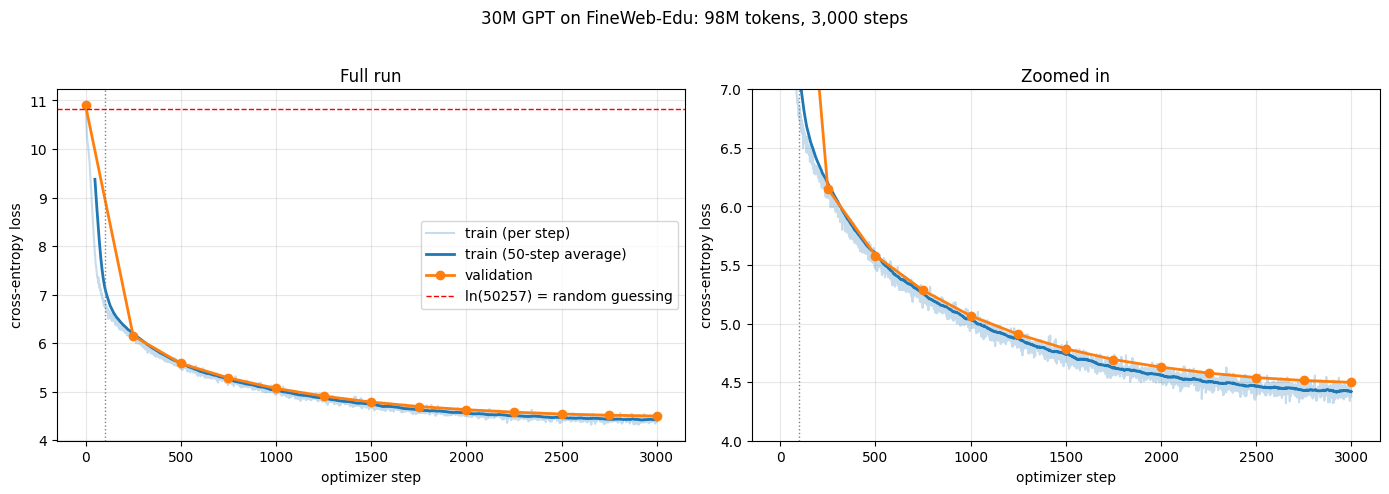

first val: 10.897 -> final val: 4.498
val loss at each eval: [10.897, 6.151, 5.581, 5.284, 5.066, 4.909, 4.785, 4.693, 4.628, 4.578, 4.539, 4.514, 4.498]


In [23]:
import json, math
import numpy as np
import matplotlib.pyplot as plt

# save the raw numbers first, so the curve can be redrawn later without retraining
with open("/kaggle/working/ckpt/history.json", "w") as f:
    json.dump(history, f)

steps = np.array(history["step"])
train = np.array(history["train_loss"])
val_steps = [0] + history["val_step"]        # step 0 = untrained baseline from Cell Y
val_loss = [10.897] + history["val_loss"]

W = 50
def smooth(y, w=W):
    return np.convolve(y, np.ones(w) / w, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for ax, zoom in zip(axes, (False, True)):
    ax.plot(steps, train, alpha=0.25, color="tab:blue", label="train (per step)")
    ax.plot(steps[W - 1:], smooth(train), color="tab:blue", lw=2, label=f"train ({W}-step average)")
    ax.plot(val_steps, val_loss, "o-", color="tab:orange", lw=2, label="validation")
    ax.axvline(100, color="gray", ls=":", lw=1)
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("cross-entropy loss")
    ax.grid(alpha=0.3)
    if zoom:
        ax.set_ylim(4.0, 7.0)
        ax.set_title("Zoomed in")
    else:
        ax.axhline(math.log(50257), color="red", ls="--", lw=1, label="ln(50257) = random guessing")
        ax.set_title("Full run")
        ax.legend()

fig.suptitle("30M GPT on FineWeb-Edu: 98M tokens, 3,000 steps", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"first val: {val_loss[0]:.3f} -> final val: {val_loss[-1]:.3f}")
print("val loss at each eval:", [round(v, 3) for v in val_loss])